Original size: (2016, 2940), Downsampled size: (504, 735)
Disparity computation time: 2.88 sec
Depth computation time: 0.05 sec


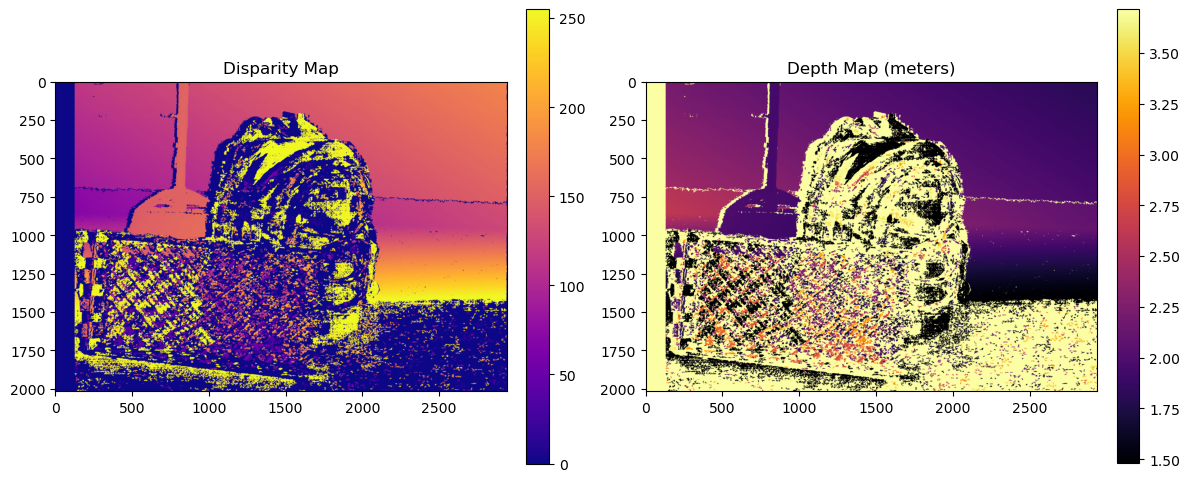

In [5]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# Load rectified grayscale images
imgL = cv2.imread("left.png", cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread("right.png", cv2.IMREAD_GRAYSCALE)

# --- Downsample images to 1/4 resolution ---
scale = 0.25
new_size = (int(imgL.shape[1] * scale), int(imgL.shape[0] * scale))
imgL_small = cv2.resize(imgL, new_size, interpolation=cv2.INTER_AREA)
imgR_small = cv2.resize(imgR, new_size, interpolation=cv2.INTER_AREA)

print(f"Original size: {imgL.shape}, Downsampled size: {imgL_small.shape}")

# --- Camera parameters (scaled) ---
f = 7190.247 * scale       # scale focal length
cx_left, cy = 1035.513 * scale, 945.196 * scale
cx_right = 1378.036 * scale
doffs = 342.523 * scale
baseline = 0.174945        # meters (baseline does NOT scale)

ndisp = 128                # fewer disparities for speed

# --- Stereo matcher (SGBM) ---
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=ndisp,
    blockSize=5,
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=50,
    speckleRange=16
)

# --- Compute disparity ---
start = time.time()
disparity = stereo.compute(imgL, imgR).astype(np.float32) / 16.0
print(f"Disparity computation time: {time.time() - start:.2f} sec")

# --- Depth calculation ---
start = time.time()
disparity = disparity + doffs
depth_map = (f * baseline) / (disparity + 1e-6)  # meters
print(f"Depth computation time: {time.time() - start:.2f} sec")

# --- Normalize disparity for visualization ---
disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp_vis = np.uint8(disp_vis)

# --- Visualization with Matplotlib ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Disparity Map")
plt.imshow(disp_vis, cmap="plasma")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,2,2)
plt.title("Depth Map (meters)")
plt.imshow(depth_map, cmap="inferno")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
